Import Libraries

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from pandas import read_csv

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, balanced_accuracy_score, accuracy_score

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

Mount Google Drive & Set Data Path

In [4]:
from google.colab import drive
drive.mount('/content/drive/')
data_path = "/content/drive/MyDrive/Colab Notebooks/Dataset/"
data = pd.read_csv(data_path + 'sensor_readings_4.csv', header=None)
data.columns = ['SD_FRONT', 'SD_LEFT', 'SD_RIGHT', 'SD_BACK', 'Classes']
num_rows_to_show = 5
display(pd.concat([data.head(num_rows_to_show), data.tail(num_rows_to_show)]))


Mounted at /content/drive/


,SD_FRONT,SD_LEFT,SD_RIGHT,SD_BACK,Classes
0,1.687,0.445,2.332,0.429,Slight-Right-Turn
1,1.687,0.449,2.332,0.429,Slight-Right-Turn
2,1.687,0.449,2.334,0.429,Slight-Right-Turn
3,1.687,0.449,2.334,0.429,Slight-Right-Turn
4,1.687,0.449,2.334,0.429,Slight-Right-Turn
5451,1.024,0.657,1.087,1.562,Move-Forward
5452,0.894,0.649,1.071,1.085,Sharp-Right-Turn
5453,0.873,0.642,1.053,1.105,Sharp-Right-Turn
5454,0.967,0.635,1.034,1.118,Move-Forward
5455,0.854,0.628,1.016,1.168,Sharp-Right-Turn


Pre-processing

In [5]:
def process_data(target_column_name):

    # Print all column names
    print("Column names in the dataset:", data.columns)

    # Check if the target column exists
    if target_column_name not in data.columns:
        raise ValueError(f"Target column {target_column_name} not found in the dataset")

    # Split the data into features and target
    X = data.drop(columns=[target_column_name])
    y = data[target_column_name]

    # Split the dataset into training and test sets
    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
    x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

    return x_train, x_test, y_train, y_test, x_val, y_val

def pre_process_data(x_train, x_test, x_val):
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    x_val_scaled = scaler.transform(x_val)

    return x_train_scaled, x_test_scaled, x_val_scaled

target_column_name = 'Classes'
class_labels = data.columns.tolist()[:-1]
X_train, X_test, y_train, y_test, X_val, y_val = process_data(target_column_name)
X_train, X_test, X_val = pre_process_data(X_train, X_test, X_val)
classes = np.unique(y_test)



Column names in the dataset: Index(['SD_FRONT', 'SD_LEFT', 'SD_RIGHT', 'SD_BACK', 'Classes'], dtype='object')


Functions

In [6]:
def print_grid_search_result(estimator_name, gs_result):
    print('Best result for', estimator_name, 'is obtained with', gs_result.best_params_)
    print('_____________________________')
    print('results (balanced accuracy) for each params settings:')
    for score, params in zip(gs_result.cv_results_['mean_test_score'], gs_result.cv_results_['params']):
        print(score, " with ", params)
    print('_____________________________')

def print_confusion_matrix(conf_matrix):
    fig, ax = plt.subplots(figsize=(10, 10))
    cax = ax.matshow(conf_matrix, cmap=plt.cm.Reds)
    fig.colorbar(cax)

    # Set grid lines based on the matrix size
    ax.set_xticks(np.arange(-.5, len(classes), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(classes), 1), minor=True)
    ax.grid(which="minor", color="black", linestyle='-', linewidth=2)
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))

    # Labels, title and ticks
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    plt.xlabel('Predictions', fontsize=16)
    plt.ylabel('Actuals', fontsize=16)
    plt.title('Confusion Matrix', fontsize=20)

    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), ha="center", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            ax.text(x=j, y=i, s=conf_matrix[i, j], va='center', ha='center', size='large')

    plt.show()

def plot_error_analysis(y_test, predicted_labels):
    correct_counts = np.zeros(len(classes))
    incorrect_counts = np.zeros(len(classes))

    # Calculate the counts of correct and incorrect predictions for each class
    for i, true_class in enumerate(classes):
        mask = (y_test == true_class)
        true_class_predictions = predicted_labels[mask]
        correct_counts[i] = np.sum(true_class_predictions == true_class)
        incorrect_counts[i] = np.sum(true_class_predictions != true_class)

    # Set the positions and width for the bars
    bar_width = 0.35
    index = np.arange(len(classes))

    # Create a grouped bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bar1 = ax.bar(index, correct_counts, bar_width, label='Correct', color='skyblue')
    bar2 = ax.bar(index + bar_width, incorrect_counts, bar_width, label='Incorrect', color='crimson')

    # Add text for labels, title and axes ticks
    ax.set_xlabel('Classes')
    ax.set_ylabel('Counts')
    ax.set_title('Error Analysis: Correct vs Incorrect Predictions for Each Class')
    ax.set_xticks(index + bar_width / 2)
    ax.set_xticklabels(classes)
    ax.legend()

    # Adding count labels over the bars
    for bar in bar1:
        height = bar.get_height()
        ax.annotate('{}'.format(int(height)),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    for bar in bar2:
        height = bar.get_height()
        ax.annotate('{}'.format(int(height)),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

    # Display the plot
    plt.tight_layout()
    plt.show()

def calculate_rates(y_true, y_pred):
    correct_predictions = sum(y_pred == y_true)
    incorrect_predictions = sum(y_pred != y_true)
    total_predictions = len(y_pred)

    success_rate = correct_predictions * 100 / total_predictions
    collision_rate = incorrect_predictions * 100 / total_predictions
    return success_rate, collision_rate

def plot_rates(success_rate, collision_rate, model_name):
    # Names of the rates
    rate_names = ['Successful Navigation Rate', 'Collision Rate']

    # Values of the rates
    rates = [success_rate, collision_rate]

    # Creating the bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(rate_names, rates, color=['green', 'red'])

    # Adding title and labels
    plt.title(f'Rates for {model_name}')
    plt.ylabel('Rate')
    for i, rate in enumerate(rates):
        plt.text(i, rate, f'{rate:.2f}', ha = 'center', va = 'bottom')

    plt.show()

Support Vector Classifier (SVC)

SVC accuracy on test data is: 94.01 %
Successful Navigation Rate: 94.01 %
Collision Rate: 5.99 %


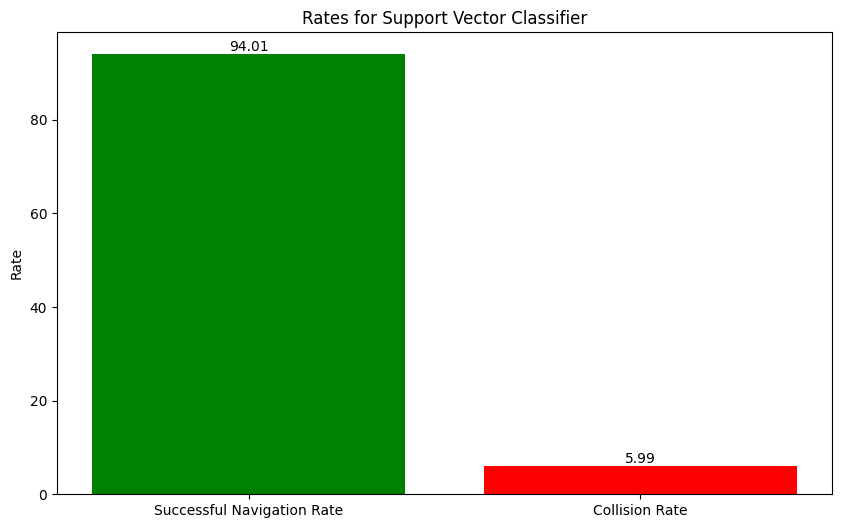

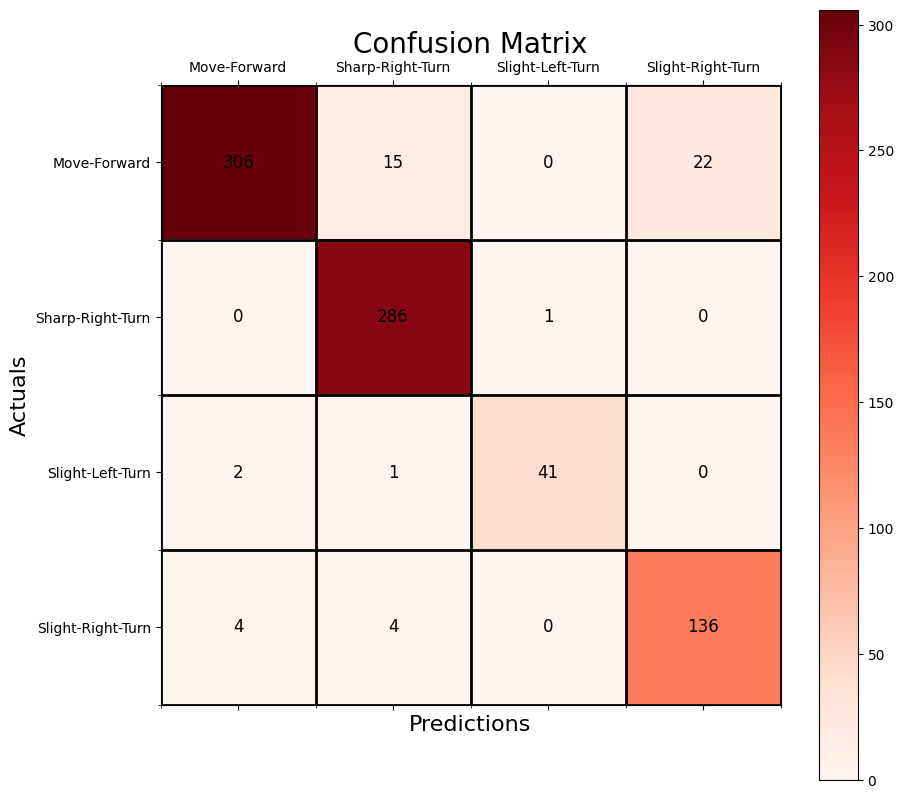

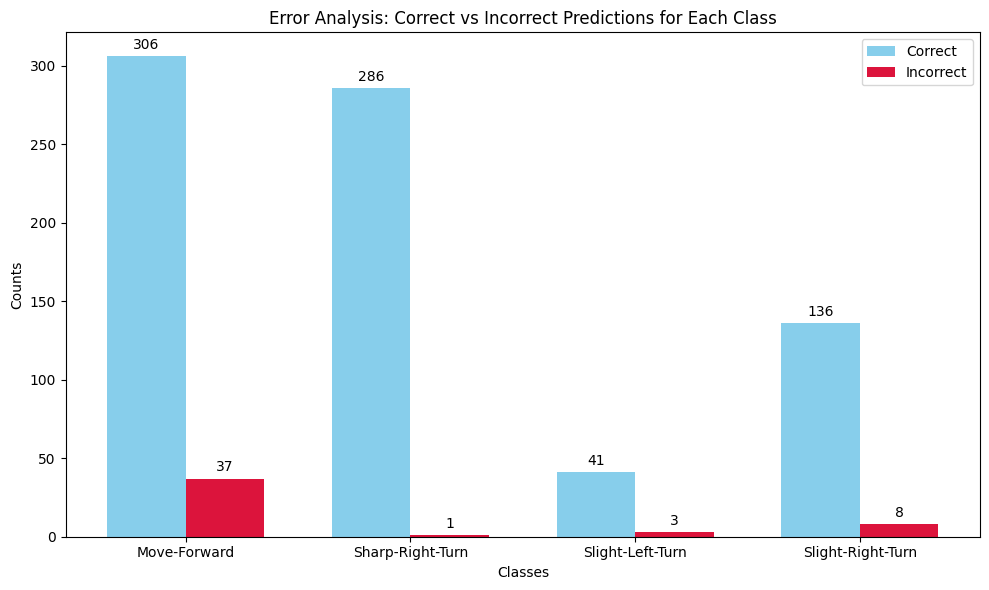

In [7]:
def train_model(x_train, y_train):
    # Initialize and train the SVC model
    model = SVC()
    model.fit(x_train, y_train)
    return model

def predict_labels(model, x_test):
    # Make predictions
    predicted_labels = model.predict(x_test)

    return predicted_labels

def evaluate_model(y_test, y_pred):
    # Calculate the accuracy on the test set
    accuracy = accuracy_score(y_test, y_pred)
    print('SVC accuracy on test data is:', f'{accuracy*100:.2f}', '%')

    # Calculate success and collision rates
    success_rate, collision_rate = calculate_rates(y_test, y_pred)
    print('Successful Navigation Rate:', f'{success_rate:.2f}', '%')
    print('Collision Rate:', f'{collision_rate:.2f}', '%')

    # Plot the rates
    model_name = 'Support Vector Classifier'
    plot_rates(success_rate, collision_rate, model_name)

    # Generate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print_confusion_matrix(conf_matrix)

ML_SVM = train_model(X_train, y_train)
predicted_labels = predict_labels(ML_SVM, X_test)
evaluate_model(y_test, predicted_labels)
plot_error_analysis(y_test, predicted_labels)

SVC using grid search

Best result for SVC is obtained with {'C': np.float64(1000.0), 'gamma': np.float64(0.005623413251903491), 'kernel': 'rbf'}
_____________________________
results (balanced accuracy) for each params settings:
0.25  with  {'C': np.float64(0.0001), 'gamma': np.float64(0.0001), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.0001), 'gamma': np.float64(0.005623413251903491), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.0001), 'gamma': np.float64(0.31622776601683794), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.0001), 'gamma': np.float64(17.78279410038923), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.0001), 'gamma': np.float64(1000.0), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.005623413251903491), 'gamma': np.float64(0.0001), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.005623413251903491), 'gamma': np.float64(0.005623413251903491), 'kernel': 'rbf'}
0.25  with  {'C': np.float64(0.005623413251903491), 'gamma': np.float64(0.31622776601683794), 'kernel': 'rbf'}
0.25  with  {'

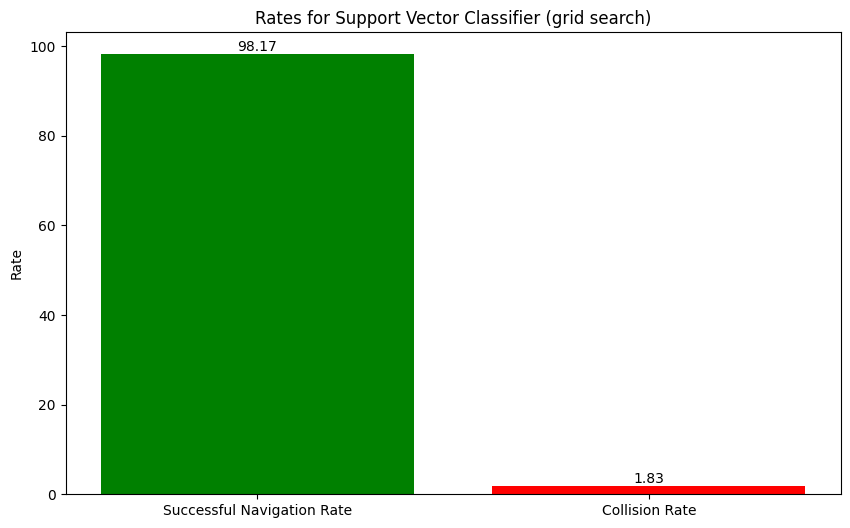

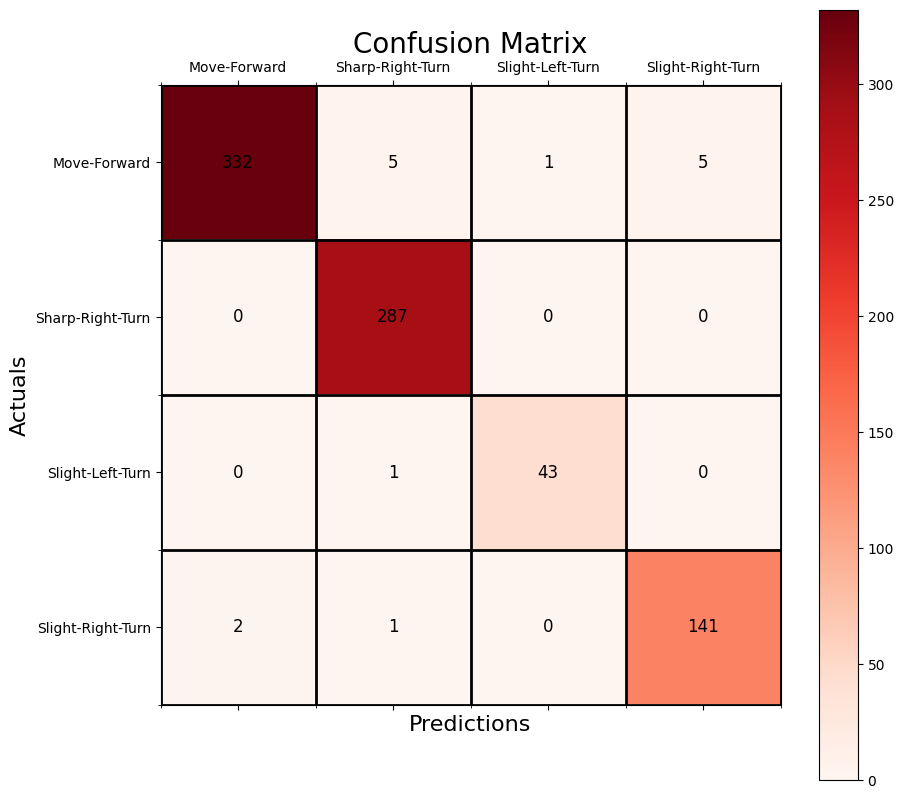

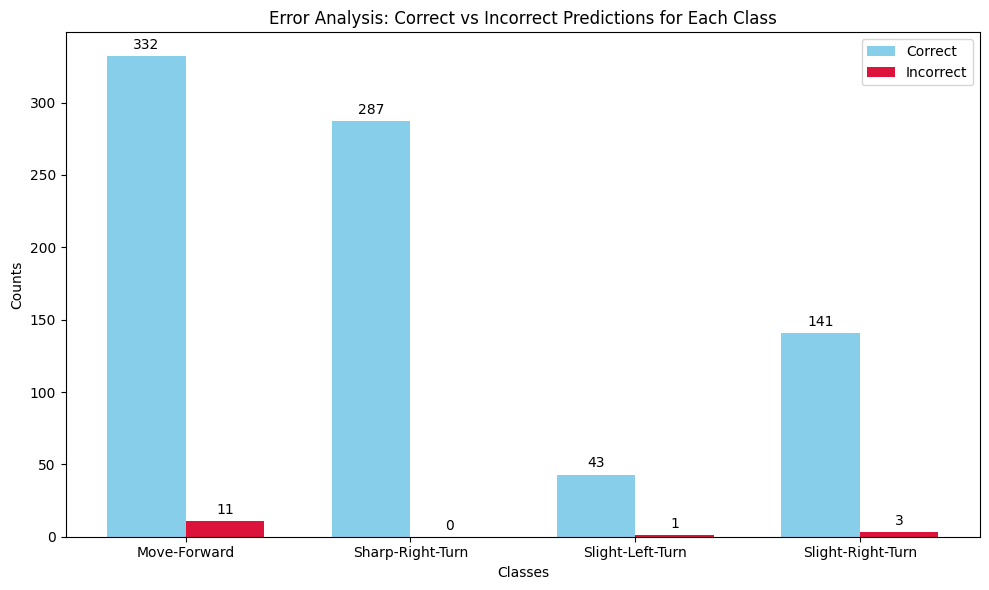

In [9]:
def train_model_grid(x_train, y_train, x_val, y_val):
    # Define the grid search parameters
    grid_search = {
        'C': np.logspace(-4, 3, 5),
        'kernel': ['rbf'],
        'gamma': np.logspace(-4, 3, 5)
    }

    # Initialize GridSearchCV
    GS = GridSearchCV(estimator=SVC(),
                    param_grid=grid_search,
                    scoring='balanced_accuracy',
                    cv=10,
                    verbose=0)

    # Find best hyperparameters
    HParam = GS.fit(x_val, y_val)

    # Print results
    print_grid_search_result('SVC', HParam)

    # Train model with best parameters
    model = SVC(C=HParam.best_params_['C'], kernel='rbf', gamma=HParam.best_params_['gamma'])
    model.fit(x_train, y_train)
    return model

def predict_labels(model, x_test):
    # Make predictions
    predicted_labels = model.predict(x_test)

    return predicted_labels

def evaluate_model(y_test, y_pred):
    # Calculate the accuracy on the test set
    accuracy = balanced_accuracy_score(y_test, y_pred)
    print('One-vs-Rest SVC accuracy on test data is:', f'{accuracy*100:.2f}', '%')

    # Calculate success and collision rates
    success_rate, collision_rate = calculate_rates(y_test, y_pred)
    print('Successful Navigation Rate:', f'{success_rate:.2f}', '%')
    print('Collision Rate:', f'{collision_rate:.2f}', '%')

    # Plot the rates
    model_name = 'Support Vector Classifier (grid search)'
    plot_rates(success_rate, collision_rate, model_name)

    # Generate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print_confusion_matrix(conf_matrix)

ML_SVM_grid = train_model_grid(X_train, y_train, X_val, y_val)
predicted_labels = predict_labels(ML_SVM_grid, X_test)
evaluate_model(y_test, predicted_labels)
plot_error_analysis(y_test, predicted_labels)

Random Forest

Random Forest accuracy on test data is: 100.00 %
Successful Navigation Rate: 100.00 %
Collision Rate: 0.00 %


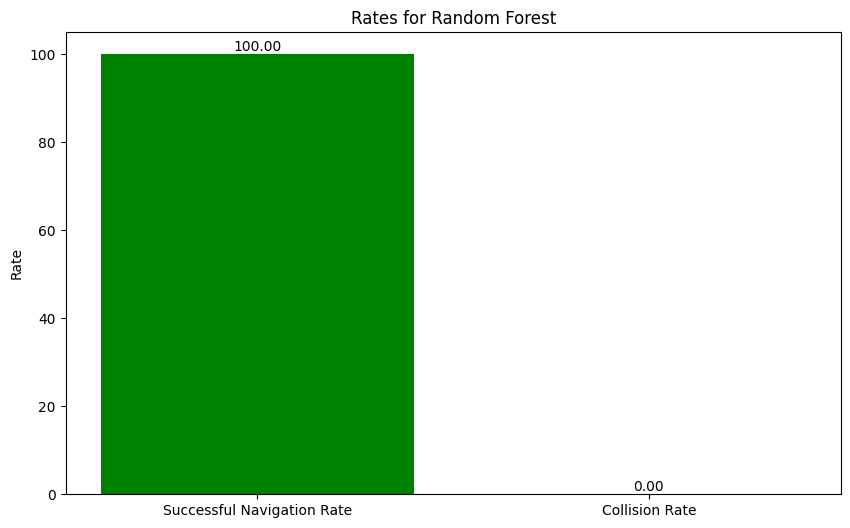

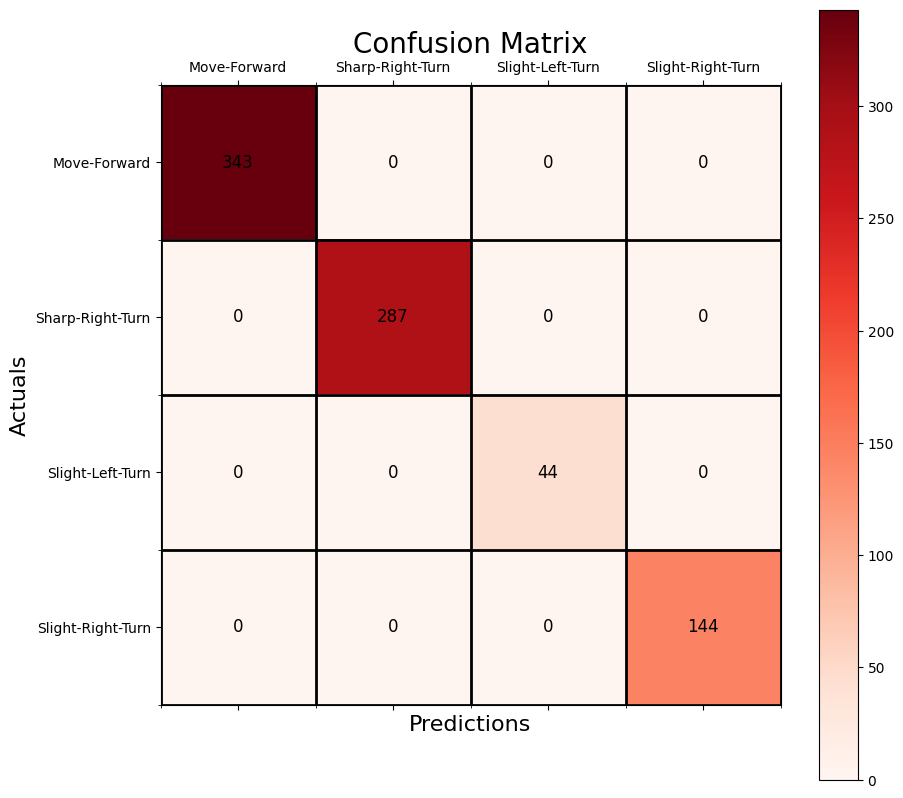

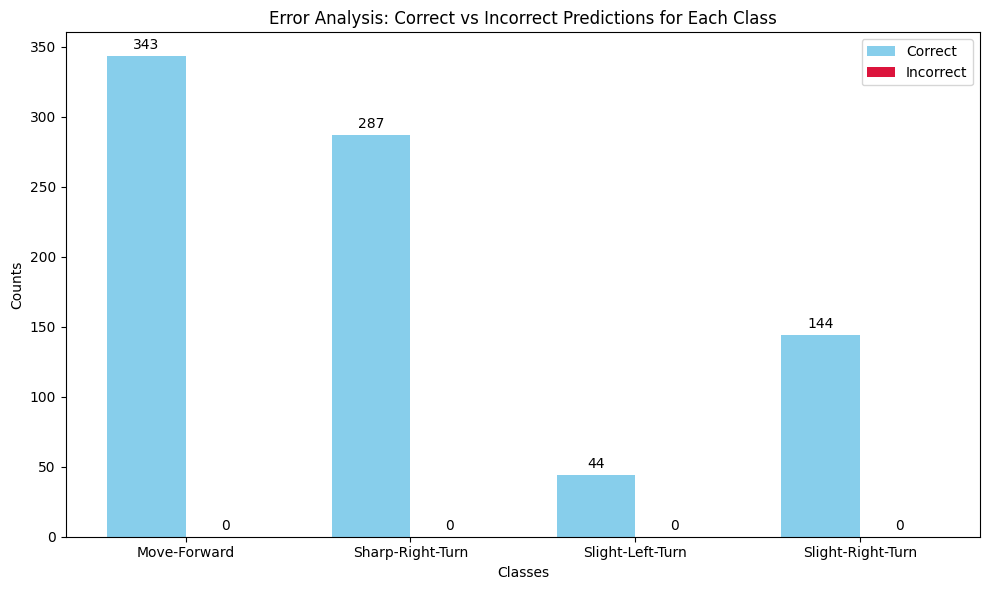

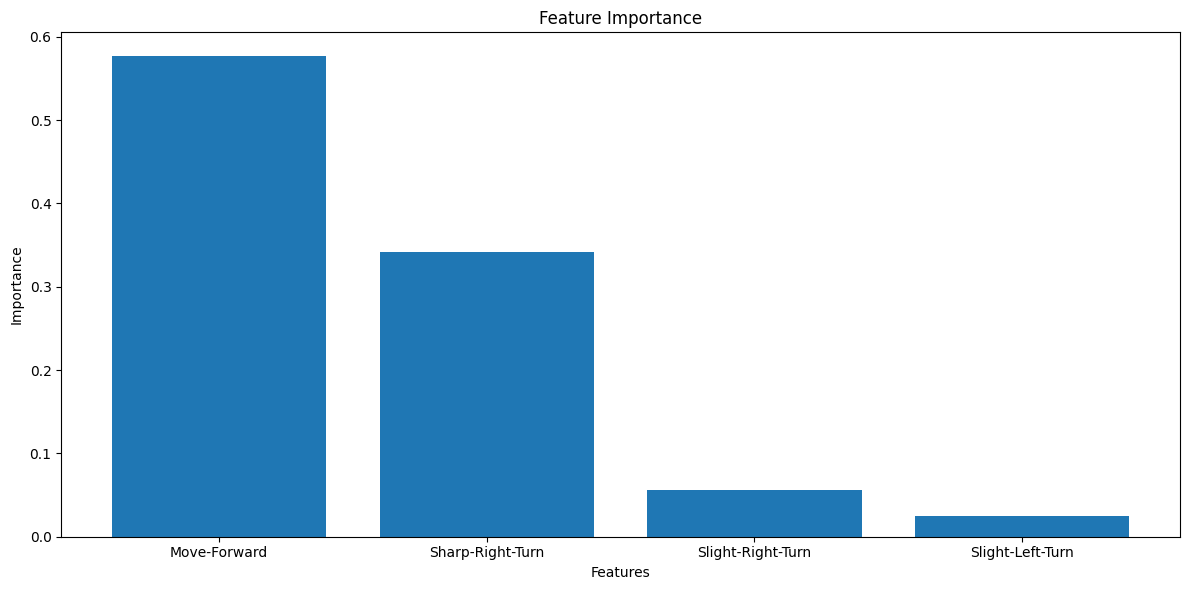

In [11]:
def train_model(x_train, y_train):
    # Initialize the Random Forest model
    model = RandomForestClassifier(random_state=42)
    model.fit(x_train, y_train)
    return model

def predict_labels(model, x_test):
    # Make predictions
    predicted_labels = model.predict(x_test)

    return predicted_labels

def evaluate_model(y_test, y_pred):
    # Calculate the accuracy on the test set

    # Calculate and print the accuracy of the classifier
    accuracy = accuracy_score(y_test, y_pred)
    print('Random Forest accuracy on test data is:', f'{accuracy*100:.2f}', '%')

    # Calculate success and collision rates
    success_rate, collision_rate = calculate_rates(y_test, y_pred)
    print('Successful Navigation Rate:', f'{success_rate:.2f}', '%')
    print('Collision Rate:', f'{collision_rate:.2f}', '%')

    # Plot the rates
    model_name = 'Random Forest'
    plot_rates(success_rate, collision_rate, model_name)

    # Generate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print_confusion_matrix(conf_matrix)

# Function for feature importance analysis
def feature_importance_analysis(model, feature_names):
    feature_importances = model.feature_importances_
    feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(12, 6))
    plt.bar(feature_importances_df['Feature'], feature_importances_df['Importance'])
    plt.xlabel('Features')
    plt.ylabel('Importance')
    plt.title('Feature Importance')
    plt.xticks(ha='center')
    plt.tight_layout()
    plt.show()

ML_RandomForest = train_model(X_train, y_train)
predicted_labels = predict_labels(ML_RandomForest, X_test)
evaluate_model(y_test, predicted_labels)
plot_error_analysis(y_test, predicted_labels)

# Perform feature importance analysis
feature_importance_analysis(ML_RandomForest, classes)

Random Forest using Grid Search

Best result for Random Forest is obtained with {'max_depth': 50, 'max_features': 'sqrt'}
_____________________________
results (balanced accuracy) for each params settings:
0.9954308712121211  with  {'max_depth': 10, 'max_features': 'sqrt'}
0.9954308712121211  with  {'max_depth': 10, 'max_features': 'log2'}
0.9954308712121211  with  {'max_depth': 10, 'max_features': None}
0.9977035984848485  with  {'max_depth': 50, 'max_features': 'sqrt'}
0.9954308712121211  with  {'max_depth': 50, 'max_features': 'log2'}
0.9954308712121211  with  {'max_depth': 50, 'max_features': None}
0.9954308712121211  with  {'max_depth': 100, 'max_features': 'sqrt'}
0.9954308712121211  with  {'max_depth': 100, 'max_features': 'log2'}
0.9954308712121211  with  {'max_depth': 100, 'max_features': None}
0.9954308712121211  with  {'max_depth': None, 'max_features': 'sqrt'}
0.9954308712121211  with  {'max_depth': None, 'max_features': 'log2'}
0.9954308712121211  with  {'max_depth': None, 'max_features': None}
__________

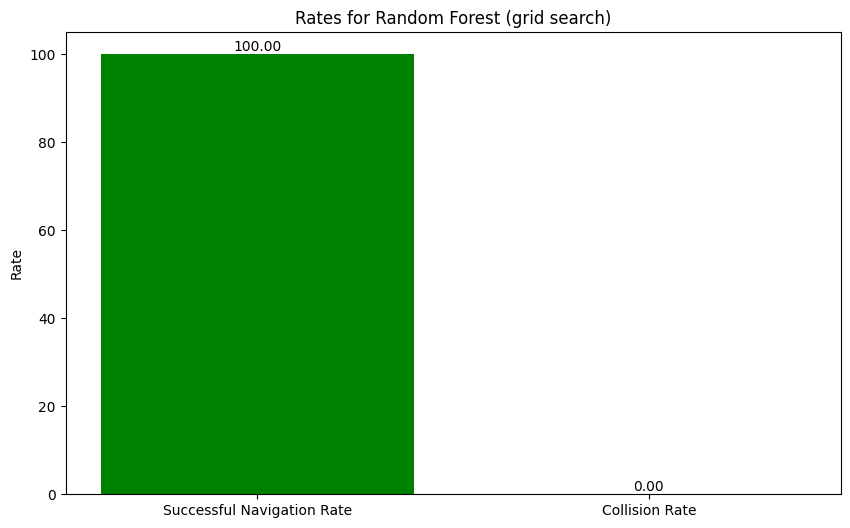

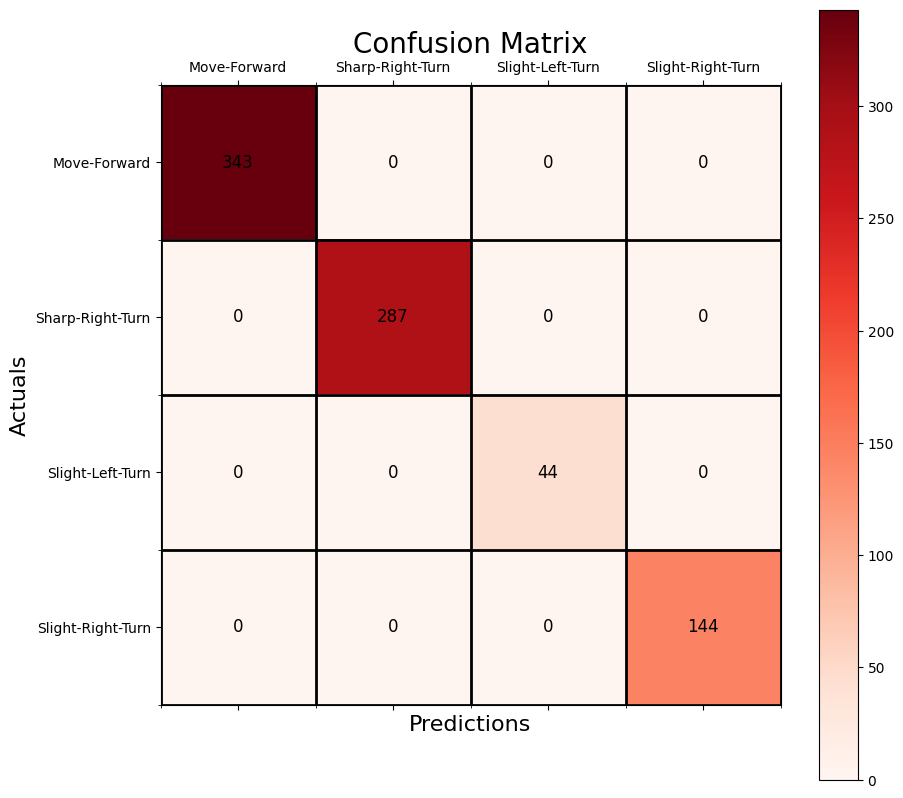

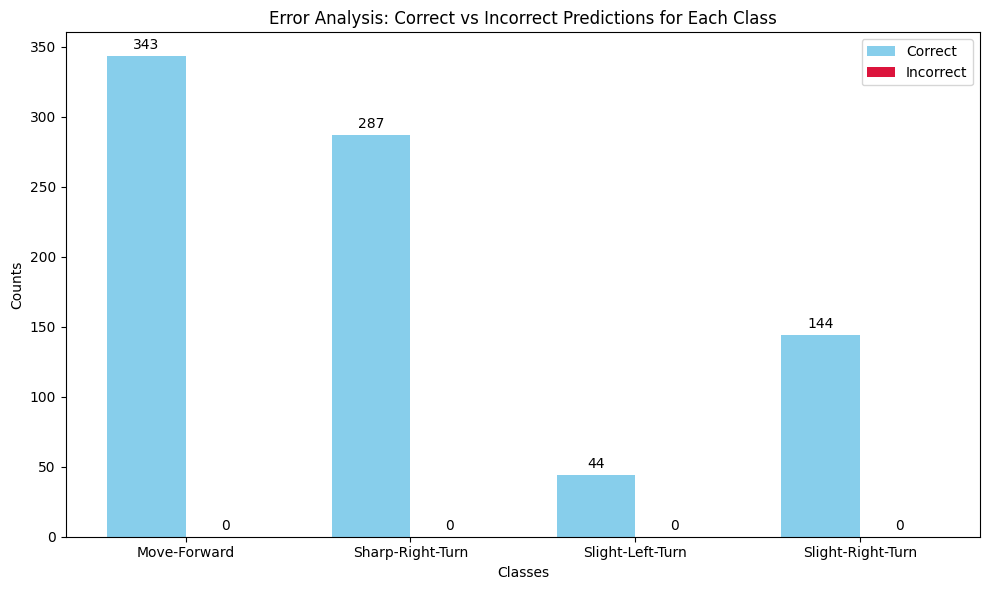

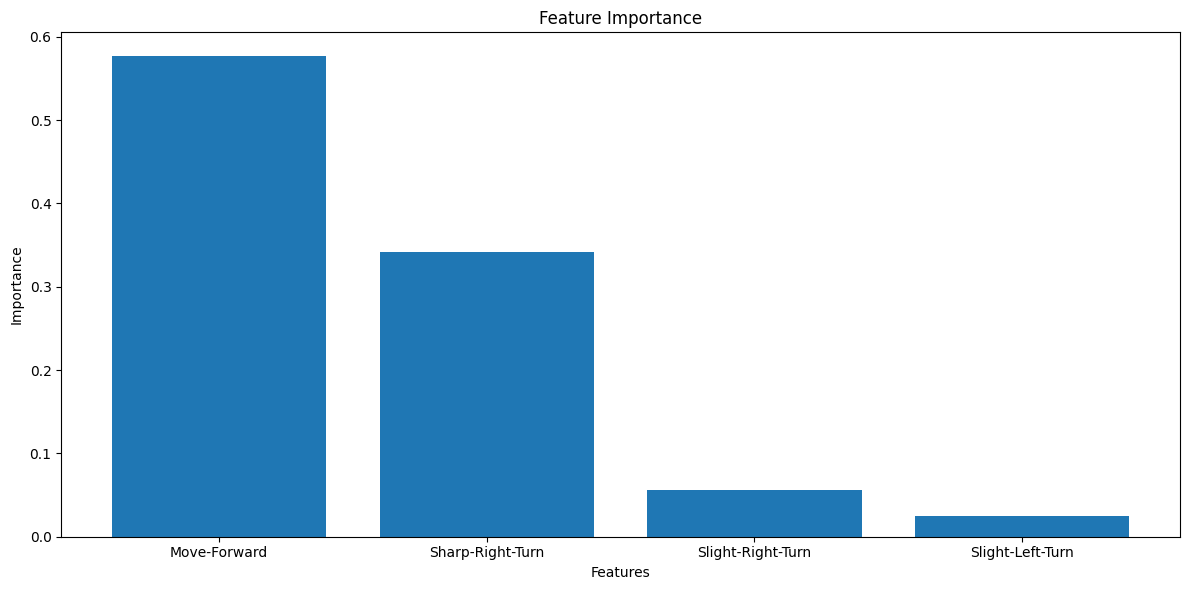

In [12]:
def train_model_grid(x_train, y_train, x_val, y_val):
    # Define the grid search parameters
    grid_search = {'max_features': ['sqrt', 'log2', None],
                   'max_depth': [10, 50, 100, None]}

    # Initialize GridSearchCV
    GS = GridSearchCV(estimator=RandomForestClassifier(),
                      param_grid=grid_search,
                      scoring='balanced_accuracy',
                      cv=10,
                      verbose=0)

    # Find best hyperparameters
    HParam = GS.fit(x_val, y_val)

    # Print results
    print_grid_search_result('Random Forest', HParam)

    # Train model with best parameters
    model = RandomForestClassifier(max_features=HParam.best_params_['max_features'],
                                max_depth=HParam.best_params_['max_depth'])
    model.fit(x_train, y_train)

    return model

def predict_labels(model, x_test):
    # Make predictions
    predicted_labels = model.predict(x_test)

    return predicted_labels

def evaluate_model(y_test, y_pred):
    # Calculate the accuracy on the test set

    # Calculate and print the accuracy of the classifier
    accuracy = accuracy_score(y_test, y_pred)
    print('Random Forest accuracy on test data is:', f'{accuracy*100:.2f}', '%')

    # Calculate success and collision rates
    success_rate, collision_rate = calculate_rates(y_test, y_pred)
    print('Successful Navigation Rate:', f'{success_rate:.2f}', '%')
    print('Collision Rate:', f'{collision_rate:.2f}', '%')

    # Plot the rates
    model_name = 'Random Forest (grid search)'
    plot_rates(success_rate, collision_rate, model_name)

    # Generate and print the confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print_confusion_matrix(conf_matrix)

ML_RandomForest_grid = train_model_grid(X_train, y_train, X_val, y_val)
predicted_labels = predict_labels(ML_RandomForest_grid, X_test)
evaluate_model(y_test, predicted_labels)
plot_error_analysis(y_test, predicted_labels)

# Perform feature importance analysis
feature_importance_analysis(ML_RandomForest, classes)